Tabela corrigida:


,Temperature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


Resumo do Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Temperature      99 non-null     int64
 1   Humidity         99 non-null     int64
 2   Moisture         99 non-null     int64
 3   Soil Type        99 non-null     str  
 4   Crop Type        99 non-null     str  
 5   Nitrogen         99 non-null     int64
 6   Potassium        99 non-null     int64
 7   Phosphorous      99 non-null     int64
 8   Fertilizer Name  99 non-null     str  
dtypes: int64(6), str(3)
memory usage: 7.1 KB


None

,Temperature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


C:\Users\gisel\AppData\Local\Temp\ipykernel_23148\3035508628.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Soil Type', data=df, ax=ax_flat[4], palette='magma')


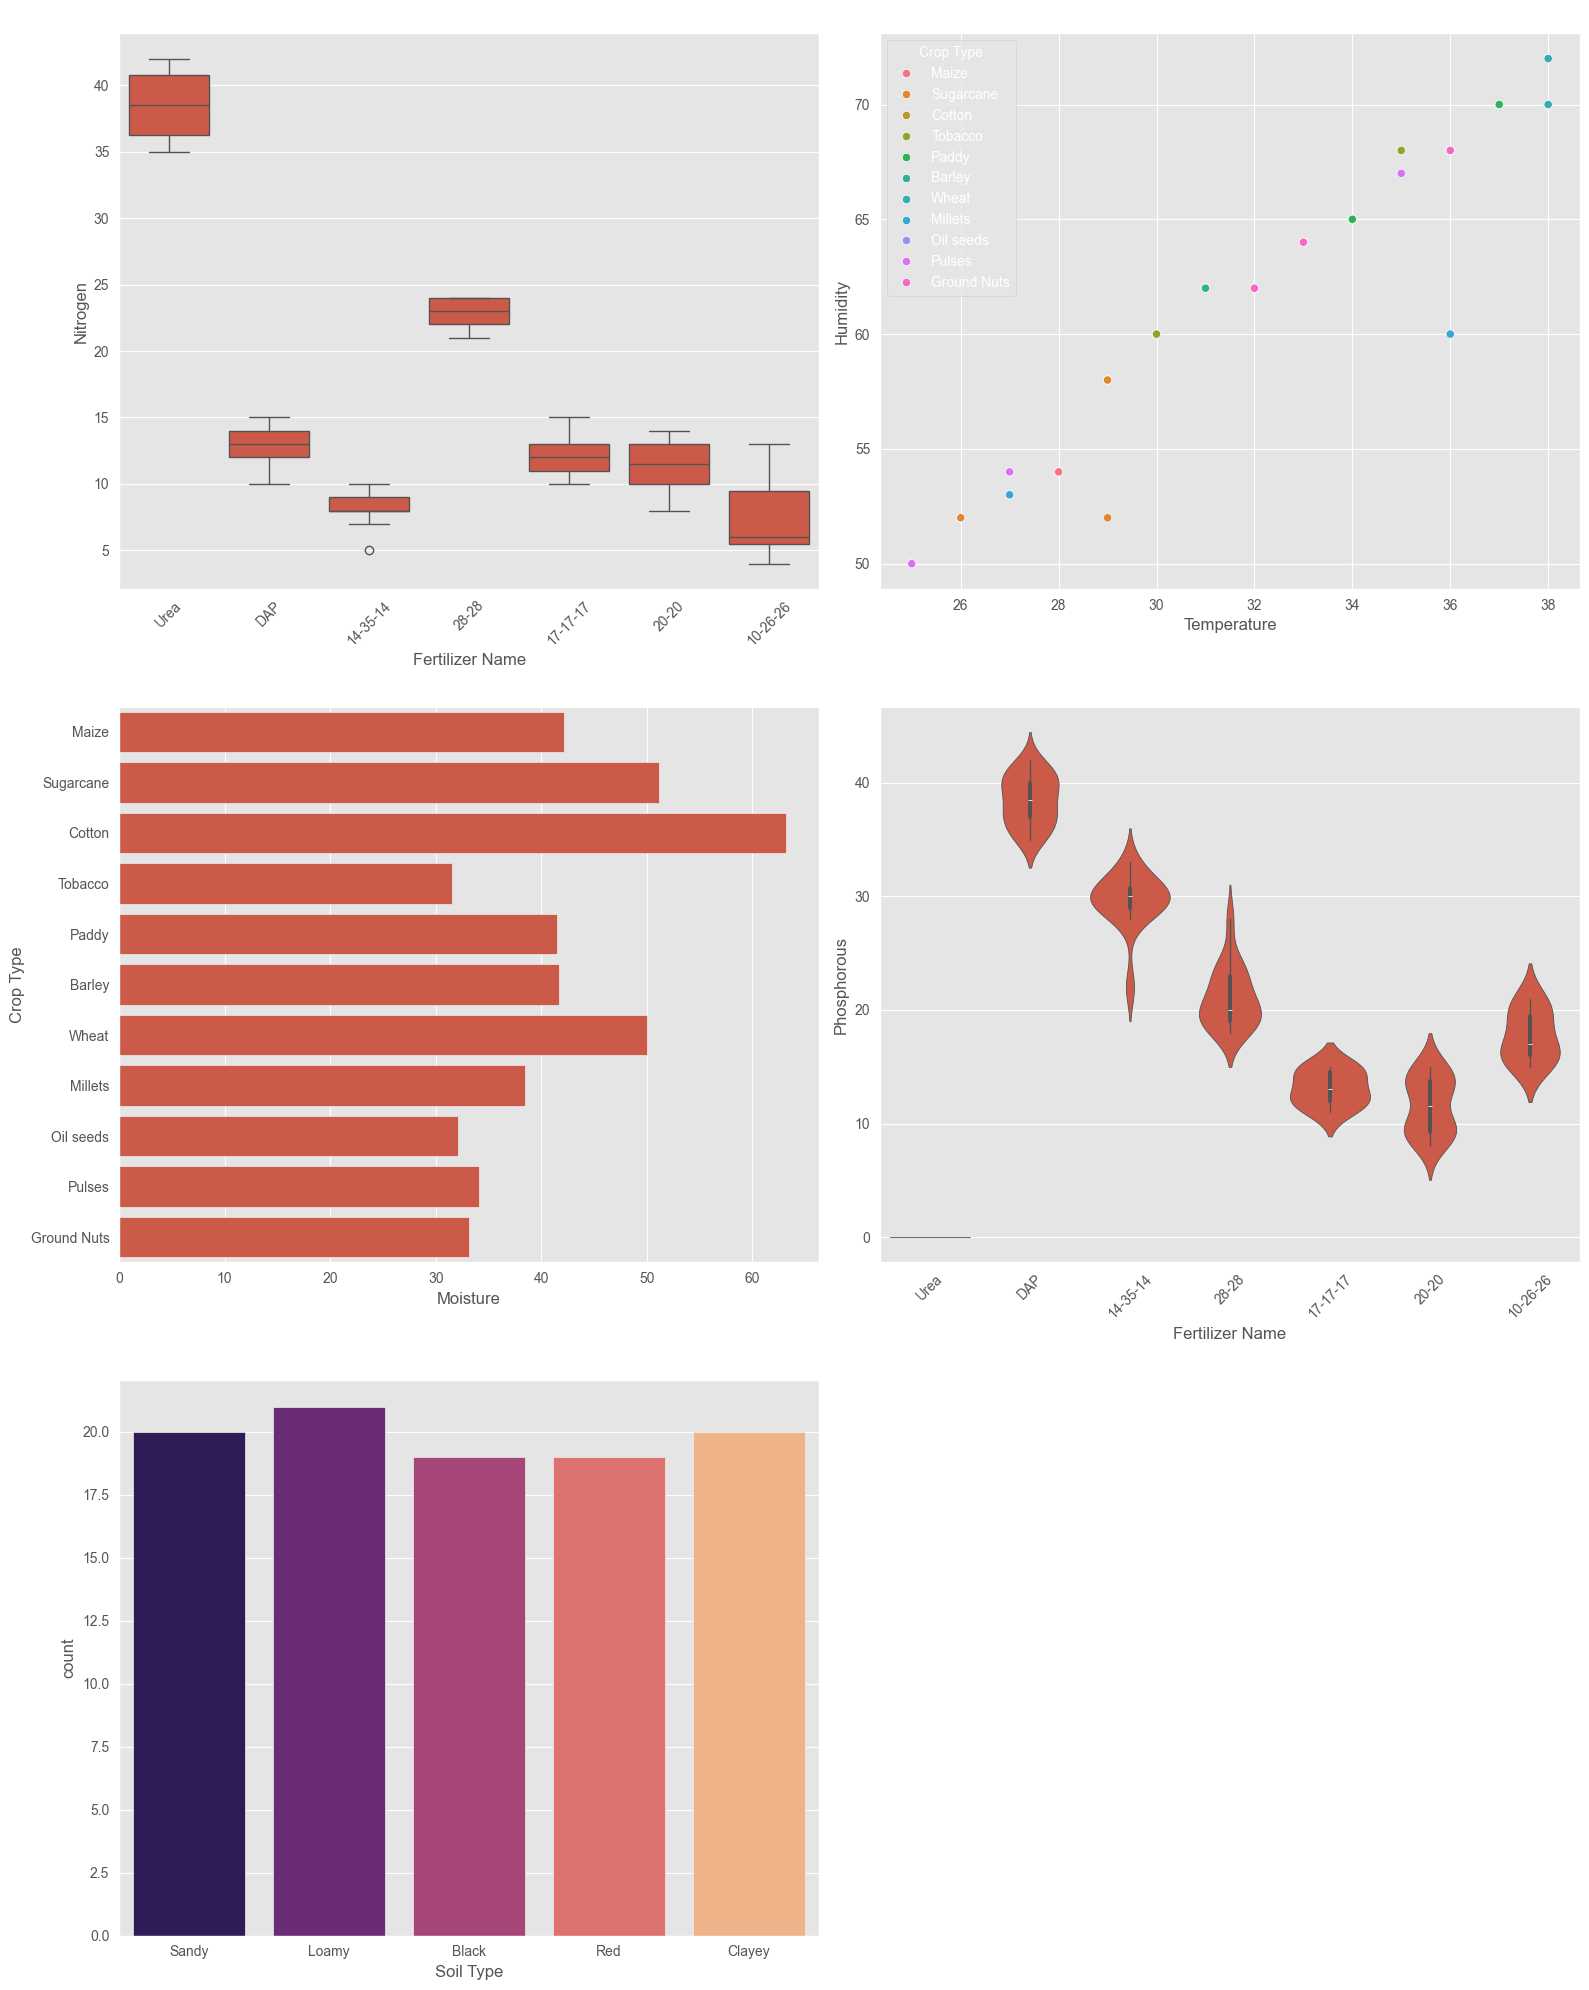

--- PERFIL MÉDIO GERAL ---
Temperature    30.282828
Humidity       59.151515
Moisture       43.181818
Nitrogen       18.909091
Potassium       3.383838
Phosphorous    18.606061
dtype: float64

--- COMPARATIVO ENTRE PRODUTOS ---


,Temperature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
Crop Type,,,,,,
Cotton,30.416667,59.583333,63.166667,16.416667,3.333333,23.833333
Maize,29.000000,57.333333,42.166667,18.333333,5.666667,18.666667
Sugarcane,30.000000,58.615385,51.153846,14.615385,4.230769,17.615385


### PERFORMANCE DOS MODELOS ###
Random Forest: Acurácia de 95.00%
Decision Tree: Acurácia de 100.00%
KNN: Acurácia de 60.00%
SVM: Acurácia de 80.00%
Gradient Boosting: Acurácia de 95.00%


In [12]:
# Relatório Técnico: Recomendação de Fertilizantes e Culturas
# **Alunos:** David Ribeiro Prado de Lacerda RM 570350 ** Giselli Mayumi Takahashi Yokoyama RM 572690 ** João Otávio de Moraes RM 573227 ** Renata de Almeida Marinho RM 569342 ** Richard Wrobel dos Santos RM 573998 **
# **Fase:** 3 | **Capítulo:** 2

# 1. Introdução e Análise Exploratória
# O objetivo deste trabalho é analisar dados agrometeorológicos e de composição do solo para identificar padrões de cultivo e desenvolver modelos preditivos para recomendação de fertilizantes.

# 2. Ajuste do arquivo no python
import pandas as pd
# O uso do parâmetro 'sep' força o Python a entender que a vírgula separa as colunas
# O 'skipinitialspace' remove espaços invisíveis que causam erros
df = pd.read_csv('fertilizer_data.csv', sep=',', skipinitialspace=True)
# Limpa espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()
# Mostra o resultado
print("Tabela corrigida:")
display(df.head())

# 3. Carregamento e limpeza
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 3.1. Carregar o arquivo que você já possui
df = pd.read_csv('fertilizer_data.csv', sep=',', skipinitialspace=True)

# 3.2. Visualização das primeiras linhas e tipos de dados
print("Resumo do Dataset:")
display(df.info())
display(df.head())

# 4. Análise descritiva (5 gráficos)

# 1. BLINDAGEM DOS DADOS: Força a limpeza de qualquer espaço invisível nas colunas
df.columns = df.columns.str.strip()

# 2. CONFIGURAÇÃO DA MATRIZ DE PLOTAGEM (3 linhas, 2 colunas)
# Usando o comando 'flatten()' para facilitar o acesso aos índices dos gráficos
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
ax_flat = axes.flatten()

# --- GRÁFICO 1: Níveis de Nitrogênio por Fertilizante (Boxplot) ---
sns.boxplot(x='Fertilizer Name', y='Nitrogen', data=df, ax=ax_flat[0])
ax_flat[0].set_title('Níveis de Nitrogênio por Fertilizante')
ax_flat[0].tick_params(axis='x', rotation=45)

# --- GRÁFICO 2: Clima Ideal por Cultura (Scatterplot) ---
# Se o seu arquivo original tiver 'Humidity ', o script corrigiu na linha 6
sns.scatterplot(x='Temperature', y='Humidity', hue='Crop Type', data=df, ax=ax_flat[1])
ax_flat[1].set_title('Clima Ideal por Cultura (Temperatura vs Umidade)')

# --- GRÁFICO 3: Média de Umidade do Solo por Cultura (Barplot) ---
sns.barplot(x='Moisture', y='Crop Type', data=df, ax=ax_flat[2], estimator=np.mean, errorbar=None)
ax_flat[2].set_title('Média de Umidade do Solo por Cultura')

# --- GRÁFICO 4: Distribuição de Fósforo por Fertilizante (Violinplot) ---
sns.violinplot(x='Fertilizer Name', y='Phosphorous', data=df, ax=ax_flat[3])
ax_flat[3].set_title('Distribuição de Fósforo por Fertilizante')
ax_flat[3].tick_params(axis='x', rotation=45)

# --- GRÁFICO 5: Distribuição dos Tipos de Solo (Countplot) ---
sns.countplot(x='Soil Type', data=df, ax=ax_flat[4], palette='magma')
ax_flat[4].set_title('Contagem de Amostras por Tipo de Solo')

# Remove o sexto espaço da matriz que ficaria em branco
fig.delaxes(ax_flat[5])

# Ajusta o espaçamento para os títulos não cortarem
plt.tight_layout()
plt.show()


# 5. Perfil ideal de comparação

# Média Geral (Perfil Médio do Dataset)
perfil_geral = df[['Temperature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']].mean()

# Comparação entre 3 culturas escolhidas: Maize, Sugarcane e Cotton (Milho, Cana de açúcar e Algodão)
culturas_escolhidas = ['Maize', 'Sugarcane', 'Cotton']
comparativo = df[df['Crop Type'].isin(culturas_escolhidas)].groupby('Crop Type')[['Temperature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']].mean()

print("--- PERFIL MÉDIO GERAL ---")
print(perfil_geral)
print("\n--- COMPARATIVO ENTRE PRODUTOS ---")
display(comparativo)

# 6. Os 5 modelos preditivos

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 6.1. Preparação dos dados
df_ml = df.copy()
le = LabelEncoder()
df_ml['Soil Type'] = le.fit_transform(df_ml['Soil Type'])
df_ml['Crop Type'] = le.fit_transform(df_ml['Crop Type'])

X = df_ml.drop('Fertilizer Name', axis=1)
y = df_ml['Fertilizer Name']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6.2. Normalização (Essencial para KNN e SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 6.3. Dicionário de Modelos
modelos = {
    "Random Forest": (RandomForestClassifier(), X_train, X_test),
    "Decision Tree": (DecisionTreeClassifier(), X_train, X_test),
    "KNN": (KNeighborsClassifier(), X_train_sc, X_test_sc),
    "SVM": (SVC(), X_train_sc, X_test_sc),
    "Gradient Boosting": (GradientBoostingClassifier(), X_train, X_test)
}

print("### PERFORMANCE DOS MODELOS ###")
for nome, (model, xtr, xts) in modelos.items():
    model.fit(xtr, y_train)
    y_pred = model.predict(xts)
    acc = accuracy_score(y_test, y_pred)
    print(f"{nome}: Acurácia de {acc:.2%}")

# 7. Conclusão e Análise de Resultados

## Considerações Principais:
##1. O **Algodão (Cotton)** exige solos significativamente mais úmidos (média > 60) em comparação ao perfil geral.
##2. Fertilizantes como **Urea** são recomendados quase exclusivamente quando o solo está pobre em Nitrogênio mas possui clima estável.
##3. Modelos baseados em **Árvores de Decisão (Random Forest/Gradient Boosting)** obtiveram melhor desempenho, pois os dados possuem regras claras de limiares nutricionais.

### Limitações:
##* O dataset possui um número reduzido de amostras, o que pode levar ao *overfitting*.
##* Variáveis como o pH do solo não foram consideradas, o que é um fator crítico na agricultura real.
